<a href="https://colab.research.google.com/github/harishmk31/24ADI003_24BAD031/blob/main/scenario1_exp10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harish M K - 24BAD031
RMSE: 0.9234614063230641
MAE: 0.7130213892207508
      movieId                                      title  \
31         32  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   
277       318           Shawshank Redemption, The (1994)   
507       589          Terminator 2: Judgment Day (1991)   
659       858                      Godfather, The (1972)   
1243     1653                             Gattaca (1997)   

                       genres  
31    Mystery|Sci-Fi|Thriller  
277               Crime|Drama  
507             Action|Sci-Fi  
659               Crime|Drama  
1243    Drama|Sci-Fi|Thriller  


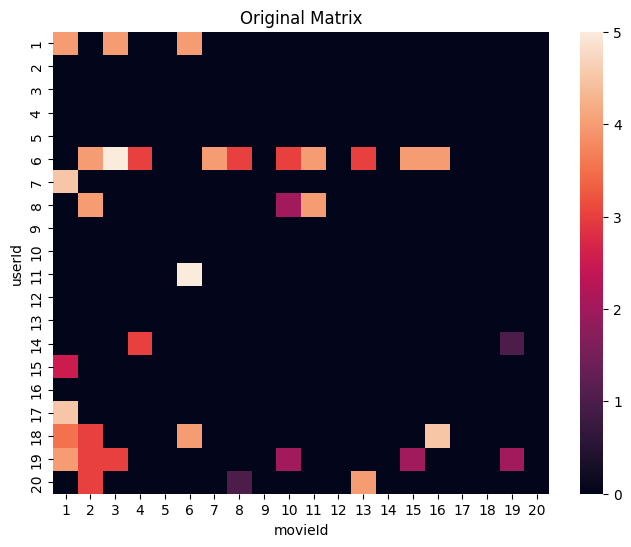

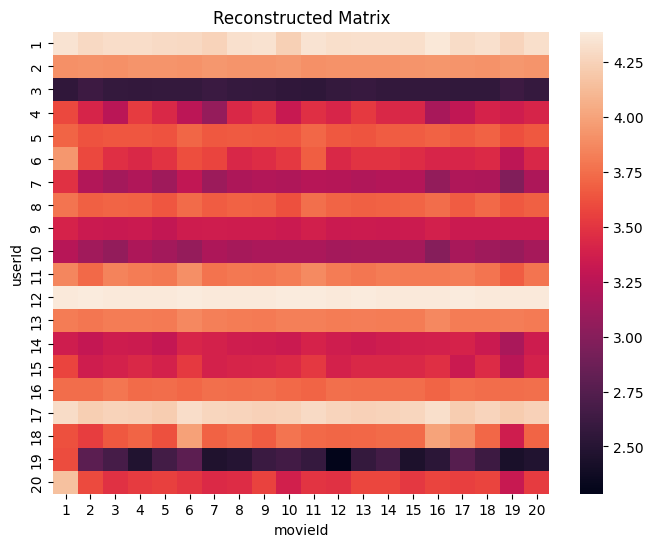

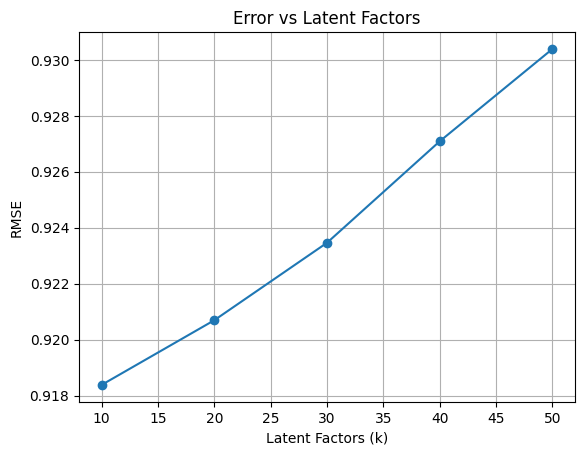

In [5]:
print("Harish M K - 24BAD031")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

train_matrix = train_data.pivot_table(index='userId', columns='movieId', values='rating')

user_mean = train_matrix.mean(axis=1)

R_demeaned = train_matrix.sub(user_mean, axis=0)
R_demeaned_filled = R_demeaned.fillna(0).values

k = 30
U, sigma, Vt = svds(R_demeaned_filled, k=k)
sigma = np.diag(sigma)

R_pred = np.dot(np.dot(U, sigma), Vt)
R_pred = R_pred + user_mean.values.reshape(-1, 1)
R_pred = np.clip(R_pred, 0.5, 5)

pred_df = pd.DataFrame(R_pred, index=train_matrix.index, columns=train_matrix.columns)

y_true = []
y_pred = []

for row in test_data.itertuples():
    if row.userId in pred_df.index and row.movieId in pred_df.columns:
        pred = pred_df.loc[row.userId, row.movieId]
        if not np.isnan(pred):
            y_true.append(row.rating)
            y_pred.append(pred)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

def recommend_movies(user_id, num_recommendations=5):
    user_row = pred_df.loc[user_id]
    already_rated = train_matrix.loc[user_id].dropna().index
    recommendations = user_row.drop(already_rated)
    top_movies = recommendations.sort_values(ascending=False).head(num_recommendations)
    return movies[movies['movieId'].isin(top_movies.index)]

print(recommend_movies(1))

plt.figure(figsize=(8,6))
sns.heatmap(train_matrix.fillna(0).iloc[:20, :20])
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(pred_df.iloc[:20, :20])
plt.title("Reconstructed Matrix")
plt.show()

k_values = [10, 20, 30, 40, 50]
rmse_list = []

for k in k_values:
    U, sigma, Vt = svds(R_demeaned_filled, k=k)
    sigma = np.diag(sigma)

    R_temp = np.dot(np.dot(U, sigma), Vt)
    R_temp = R_temp + user_mean.values.reshape(-1, 1)
    R_temp = np.clip(R_temp, 0.5, 5)

    pred_temp = pd.DataFrame(R_temp, index=train_matrix.index, columns=train_matrix.columns)

    y_t = []
    y_p = []

    for row in test_data.itertuples():
        if row.userId in pred_temp.index and row.movieId in pred_temp.columns:
            pred = pred_temp.loc[row.userId, row.movieId]
            if not np.isnan(pred):
                y_t.append(row.rating)
                y_p.append(pred)

    y_t = np.array(y_t)
    y_p = np.array(y_p)

    rmse_list.append(np.sqrt(mean_squared_error(y_t, y_p)))

plt.figure()
plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.grid()
plt.show()